In [94]:
import os
import numpy as np
import cv2
import pandas as pd
import pyzed.sl as sl
from tqdm import tqdm
import open3d as o3d

import matplotlib.pyplot as plt
from pathlib import Path


class DatasetConverter:
    """Convert SVO2 dataset to frame-based dataset"""
    
    def __init__(self, dataset_dir):
        self.dataset_dir = Path(dataset_dir)
        
        # Check if dataset exists
        if not self.dataset_dir.exists():
            raise ValueError(f"Dataset not found: {dataset_dir}")
        
        # Find SVO files
        self.svo_files = {
            'front': self.dataset_dir / "rgbd_front.svo2",
            'back': self.dataset_dir / "rgbd_back.svo2"
        }
        
        # Find LiDAR files
        self.lidar_pc_file = self.dataset_dir / "lidar_pointcloud.bin"
        self.lidar_imu_file = self.dataset_dir / "lidar_imu.bin"
        
        print(f"[Converter] Dataset loaded: {dataset_dir}")
        self._check_files()
    
    def _check_files(self):
        """Check which files exist"""
        for name, path in self.svo_files.items():
            if path.exists():
                print(f"  ✓ {name} SVO2: {path.name}")
            else:
                print(f"  ✗ {name} SVO2 not found")
        
        if self.lidar_pc_file.exists():
            print(f"  ✓ LiDAR PointCloud: {self.lidar_pc_file.name}")
        else:
            print(f"  ✗ LiDAR PointCloud not found")
        
        if self.lidar_imu_file.exists():
            print(f"  ✓ LiDAR IMU: {self.lidar_imu_file.name}")
        else:
            print(f"  ✗ LiDAR IMU not found")

    def visualize_first_pointcloud(self):
        
        with open(self.lidar_pc_file, 'rb') as f:
            # Read first frame
            sec = np.frombuffer(f.read(4), dtype=np.int32)[0]
            nanosec = np.frombuffer(f.read(4), dtype=np.int32)[0]
            num_points = np.frombuffer(f.read(4), dtype=np.int32)[0]
            points = np.frombuffer(f.read(num_points * 4 * 4), dtype=np.float32).reshape(-1, 4)
            
            print(f"\nFirst Point Cloud:")
            print(f"  Timestamp: {sec}.{nanosec:09d}")
            print(f"  Num points: {num_points}")
            print(f"  Point range: X[{points[:, 0].min():.2f}, {points[:, 0].max():.2f}] "
                f"Y[{points[:, 1].min():.2f}, {points[:, 1].max():.2f}] "
                f"Z[{points[:, 2].min():.2f}, {points[:, 2].max():.2f}]")
            
            # Visualize with matplotlib (4 views)
            self._plot_pointcloud_3views(points)

    def _plot_pointcloud_3views(self, points):
        """Plot point cloud from 4 different views"""
        fig = plt.figure(figsize=(16, 5))
        
        # Color by intensity
        intensity = points[:, 3]
        colors = plt.cm.viridis((intensity - intensity.min()) / (intensity.max() - intensity.min() + 1e-6))
        
        # 1. XY plane (top view)
        ax1 = fig.add_subplot(1, 3, 1)
        ax1.scatter(points[:, 0], points[:, 1], c=colors, s=0.5, alpha=0.6)
        ax1.set_xlabel('X (m)')
        ax1.set_ylabel('Y (m)')
        ax1.set_title('Top View (XY Plane)')
        ax1.axis('equal')
        ax1.grid(True, alpha=0.3)
        
        # 2. YZ plane (side view)
        ax2 = fig.add_subplot(1, 3, 2)
        ax2.scatter(points[:, 1], points[:, 2], c=colors, s=0.5, alpha=0.6)
        ax2.set_xlabel('Y (m)')
        ax2.set_ylabel('Z (m)')
        ax2.set_title('Side View (YZ Plane)')
        ax2.axis('equal')
        ax2.grid(True, alpha=0.3)
        
        # 3. ZX plane (front view)
        ax3 = fig.add_subplot(1, 3, 3)
        ax3.scatter(points[:, 0], points[:, 2], c=colors, s=0.5, alpha=0.6)
        ax3.set_xlabel('X (m)')
        ax3.set_ylabel('Z (m)')
        ax3.set_title('Front View (ZX Plane)')
        ax3.axis('equal')
        ax3.grid(True, alpha=0.3)
        
        plt.tight_layout()
        
        # Save to file
        output_path = './pointcloud_3views.png'
        plt.savefig(output_path, dpi=150, bbox_inches='tight')
        print(f"\nPoint cloud visualization saved to: {output_path}")
        plt.show()
        
        
    def convert_to_frames(self, hz=10, max_frames=None):
        """
        Convert SVO2 dataset to frame-based dataset
        
        Args:
            output_dir: Output directory for converted dataset
            hz: Extraction frequency (frames per second)
            max_frames: Maximum number of frames to extract (None for all)
        """
        
        frame_interval = 1.0 / hz  # seconds between frames
        
        print(f"\n[Converter] Starting conversion at {hz} Hz")
        print(f"  Frame interval: {frame_interval:.3f}s")
        
        # Convert each SVO2 file
        all_timestamps = {}
        
        for camera_name, svo_path in self.svo_files.items():
            if not svo_path.exists():
                print(f"Skipping {camera_name} (file not found)")
                continue
            
            print(f"\nProcessing {camera_name} camera...")
            timestamps = self._extract_svo_frames(
                svo_path, camera_name, hz, max_frames
            )
            all_timestamps[camera_name] = timestamps
        
        # Load and align LiDAR data
        print("\nProcessing LiDAR data...")
        lidar_data = self._load_lidar_data()
        imu_data = self._load_imu_data()
        
        # Create synchronization CSV
        self._create_sync_csv(all_timestamps, lidar_data, imu_data)
        
    
    def _extract_svo_frames(self, svo_path, camera_name, hz, max_frames):
        """Extract frames from SVO2 file"""
        # Create output directories
        rgb_dir = self.dataset_dir / f"RGBD_{camera_name}" / "rgb"
        depth_dir = self.dataset_dir  / f"RGBD_{camera_name}" / "depth"
        rgb_dir.mkdir(parents=True, exist_ok=True)
        depth_dir.mkdir(parents=True, exist_ok=True)
        
        # Open SVO file
        cam = sl.Camera()
        init_params = sl.InitParameters()
        init_params.set_from_svo_file(str(svo_path))
        init_params.svo_real_time_mode = False  # Process as fast as possible
        
        status = cam.open(init_params)
        if status != sl.ERROR_CODE.SUCCESS:
            print(f"Failed to open SVO: {status}")
            return []
        
        # Get total frames
        total_frames = cam.get_svo_number_of_frames()
        print(f"  Total frames in SVO: {total_frames}")
        
        frame_interval = 1.0 / hz
        runtime = sl.RuntimeParameters()
        image_rgb = sl.Mat()
        image_depth = sl.Mat()
        
        timestamps = []
        last_extract_time = -frame_interval
        frame_count = 0
        
        pbar = tqdm(total=min(total_frames, max_frames) if max_frames else total_frames, 
                    desc=f"  Extracting {camera_name}")
        
        while True:
            if max_frames and frame_count >= max_frames:
                break
            
            if cam.grab(runtime) == sl.ERROR_CODE.SUCCESS:
                # Get timestamp
                zed_timestamp = cam.get_timestamp(sl.TIME_REFERENCE.IMAGE)
                current_time = zed_timestamp.get_nanoseconds()
                
                # Check if we should extract this frame
                if current_time - last_extract_time >= frame_interval:
                    sec = int(zed_timestamp.get_seconds())
                    nanosec = int(str(current_time)[10:])
                    
                    # Retrieve RGB
                    cam.retrieve_image(image_rgb, sl.VIEW.LEFT)
                    rgb_np = image_rgb.get_data()
                    rgb_img = cv2.cvtColor(rgb_np, cv2.COLOR_RGBA2RGB)
                    
                    # Retrieve Depth
                    cam.retrieve_measure(image_depth, sl.MEASURE.DEPTH)
                    depth_np = image_depth.get_data()
                    
                    # Save files
                    timestamp_str = f"{sec}_{nanosec:09d}"
                    
                    rgb_path = rgb_dir / f"{timestamp_str}.jpg"
                    cv2.imwrite(str(rgb_path), rgb_img, [cv2.IMWRITE_JPEG_QUALITY, 85])
                    
                    depth_mm = np.clip(depth_np, 0, 65535).astype(np.uint16)
                    depth_path = depth_dir / f"{timestamp_str}.png"
                    cv2.imwrite(str(depth_path), depth_mm)
                    
                    timestamps.append({
                        'sec': sec,
                        'nanosec': nanosec,
                        'timestamp': current_time,
                        'rgb_path': rgb_path,
                        'depth_path': depth_path
                    })
                    
                    last_extract_time = current_time
                    frame_count += 1
                    pbar.update(1)
            else:
                break
        
        pbar.close()
        cam.close()
        
        print(f"  Extracted {frame_count} frames")
        return timestamps
    
    def _load_lidar_data(self):
        """Load all LiDAR point clouds"""
        if not self.lidar_pc_file.exists():
            return []
        
        lidar_data = []
        with open(self.lidar_pc_file, 'rb') as f:
            while True:
                # Read timestamp
                sec_bytes = f.read(4)
                if len(sec_bytes) < 4:
                    break
                
                sec = np.frombuffer(sec_bytes, dtype=np.int32)[0]
                nanosec = np.frombuffer(f.read(4), dtype=np.int32)[0]
                num_points = np.frombuffer(f.read(4), dtype=np.int32)[0]
                points = np.frombuffer(f.read(num_points * 4 * 4), dtype=np.float32).reshape(-1, 4)
                timestamp = int(str(sec) + f"{nanosec:09d}")
                lidar_data.append({
                    'sec': sec,
                    'nanosec': nanosec,
                    'timestamp': timestamp,
                    'points': points,
                })
        
        print(f"  Loaded {len(lidar_data)} LiDAR scans")
        return lidar_data
    
    def _load_imu_data(self):
        """Load all IMU data"""
        if not self.lidar_imu_file.exists():
            return []
        
        imu_data = []
        with open(self.lidar_imu_file, 'rb') as f:
            while True:
                data_bytes = f.read(12 * 4)  # 12 floats
                if len(data_bytes) < 12 * 4:
                    break
                
                data = np.frombuffer(data_bytes, dtype=np.float32)
                sec, nanosec = int(data[0]), int(data[1])
                timestamp = int(str(sec) + f"{nanosec:09d}")
                
                imu_data.append({
                    'sec': sec,
                    'nanosec': nanosec,
                    'timestamp': timestamp,
                    'accel': data[2:5],
                    'gyro': data[5:8],
                    'quat': data[8:12]
                })
        
        print(f"  Loaded {len(imu_data)} IMU samples")
        return imu_data
    
    def _create_sync_csv(self, camera_timestamps, lidar_data, imu_data, ts_threshold=500000000):
        """Create synchronized data CSV"""
        if not camera_timestamps:
            print("No camera data to synchronize")
            return
        
        # Use first available camera as reference
        ref_camera = list(camera_timestamps.keys())[0]
        ref_timestamps = camera_timestamps[ref_camera]

        lidar_times = np.array([d['timestamp'] for d in lidar_data])
        imu_times = np.array([d['timestamp'] for d in imu_data])

        sync_data = []
        
        for ref_frame in ref_timestamps:
            ref_time = ref_frame['timestamp']
            
            sync_entry = {
                'timestamp': ref_time,
                'sec': ref_frame['sec'],
                'nanosec': ref_frame['nanosec']
            }
            
            # Add all camera data
            for cam_name, cam_ts in camera_timestamps.items():
                # Find closest timestamp
                closest_idx = min(range(len(cam_ts)), 
                                 key=lambda i: abs(cam_ts[i]['timestamp'] - ref_time))
                
                if abs(cam_ts[closest_idx]['timestamp'] - ref_time) < ts_threshold:  # Within 0.05s, 50ms
                    sync_entry[f'{cam_name}_rgb'] = cam_ts[closest_idx]['rgb_path']
                    sync_entry[f'{cam_name}_depth'] = cam_ts[closest_idx]['depth_path']
                else:
                    sync_entry[f'{cam_name}_rgb'] = None
                    sync_entry[f'{cam_name}_depth'] = None
            
            # Find closest LiDAR

            closest_idx = np.argmin(np.abs(lidar_times - ref_time))
            if abs(lidar_times[closest_idx] - ref_time) < ts_threshold:  
                sync_entry['lidar_idx'] = closest_idx
            else:
                sync_entry['lidar_idx'] = None
            
            closest_idx = np.argmin(np.abs(imu_times - ref_time))
            if abs(imu_times[closest_idx] - ref_time) < ts_threshold:  
                sync_entry['imu_idx'] = closest_idx
            else:
                sync_entry['imu_idx'] = None
            
            sync_data.append(sync_entry)
        
        # Save CSV
        df = pd.DataFrame(sync_data)
        csv_path = self.dataset_dir / "time_sync_data.csv"
        df.to_csv(csv_path, index=False)
        
        print(f"  Sync CSV saved: {csv_path}")
        print(f"  Total synchronized frames: {len(sync_data)}")


class DatasetLoader:
    """Load converted dataset with synchronized data"""
    
    def __init__(self, dataset_dir):
        self.dataset_dir = Path(dataset_dir)
        
        # Load sync CSV
        self.sync_csv = pd.read_csv(self.dataset_dir / "time_sync_data.csv")
        
        # Load LiDAR data (keep in memory for fast access)
        
        lidar_pc_file = self.dataset_dir / "lidar_pointcloud.bin"
        lidar_imu_file = self.dataset_dir / "lidar_imu.bin"
        
        print(f"[Loader] Loading dataset: {dataset_dir}")
        
        self.lidar_data = self._load_lidar_data(lidar_pc_file)
    
        self.imu_data = self._load_imu_data(lidar_imu_file)
    
        print(f"  Total frames: {len(self.sync_csv)}")
    
    def _load_lidar_data(self, lidar_pc_file):
        """Load LiDAR data"""
        lidar_data = []
        with open(lidar_pc_file, 'rb') as f:
            while True:
                sec_bytes = f.read(4)
                if len(sec_bytes) < 4:
                    break
                
                sec = np.frombuffer(sec_bytes, dtype=np.int32)[0]
                nanosec = np.frombuffer(f.read(4), dtype=np.int32)[0]
                num_points = np.frombuffer(f.read(4), dtype=np.int32)[0]
                points = np.frombuffer(f.read(num_points * 4 * 4), dtype=np.float32).reshape(-1, 4)
                
                lidar_data.append(points)
        
        print(f"  Loaded {len(lidar_data)} LiDAR scans")
        return lidar_data

            
    def _load_imu_data(self, lidar_imu_file):
        """Load IMU data"""
        imu_data = []
        with open(lidar_imu_file, 'rb') as f:
            while True:
                data_bytes = f.read(12 * 4)
                if len(data_bytes) < 12 * 4:
                    break
                
                data = np.frombuffer(data_bytes, dtype=np.float32)
                imu_data.append({
                    'accel': data[2:5],
                    'gyro': data[5:8],
                    'quat': data[8:12]
                })
        
        print(f"  Loaded {len(imu_data)} IMU samples")
        return imu_data
    
    def get_frame(self, idx):
        """
        Get synchronized frame data
        
        Returns:
            dict with keys: front_rgb, front_depth, back_rgb, back_depth, 
                           lidar_pc, lidar_imu (if available)
        """
        if idx >= len(self.sync_csv):
            raise IndexError(f"Frame index {idx} out of range (total: {len(self.sync_csv)})")
        row = self.sync_csv.iloc[idx]
        result = {}
        
        # Load camera data
        for camera in ['front', 'back']:
            rgb_key = f'{camera}_rgb'
            depth_key = f'{camera}_depth'
            result[f'{camera}_rgb'] = cv2.imread(str(row[rgb_key]))
            result[f'{camera}_rgb'] = cv2.cvtColor(result[f'{camera}_rgb'], cv2.COLOR_BGR2RGB)
        
            depth_mm = cv2.imread(str(row[depth_key]), cv2.IMREAD_UNCHANGED)
            result[f'{camera}_depth'] = depth_mm / 1000.0  # mm to meters
    
        # Load LiDAR
        lidar_idx = int(row['lidar_idx'])
        result['lidar_pc'] = self.lidar_data[lidar_idx]

        result['timestamp'] = row['timestamp']
        
        return result
    
    def __len__(self):
        return len(self.sync_csv)
    
    def __getitem__(self, idx):
        return self.get_frame(idx)

def visualize_frame(frame_data):
    """Visualize a synchronized frame"""
    fig = plt.figure(figsize=(20, 10))
    
    plot_idx = 1
    
    # RGB images
    for camera in ['front', 'back']:
        rgb_key = f'{camera}_rgb'
        if frame_data[rgb_key] is not None:
            ax = fig.add_subplot(2, 2, plot_idx)
            ax.imshow(frame_data[rgb_key])
            ax.set_title(f'{camera.capitalize()} RGB')
            ax.axis('off')
            plot_idx += 1
    
    # Depth images
    for camera in ['front', 'back']:
        depth_key = f'{camera}_depth'
        if frame_data[depth_key] is not None:
            ax = fig.add_subplot(2, 2, plot_idx)
            im = ax.imshow(frame_data[depth_key], cmap='viridis')
            ax.set_title(f'{camera.capitalize()} Depth')
            ax.axis('off')
            plt.colorbar(im, ax=ax, label='Depth (m)')
            plot_idx += 1
    
    # Save camera images
    plt.tight_layout()
    camera_output = './frame_cameras.png'
    plt.savefig(camera_output, dpi=150, bbox_inches='tight')
    print(f"Camera visualization saved to: {camera_output}")
    plt.show()

    # Visualize LiDAR if available with matplotlib 4 views
    if frame_data['lidar_pc'] is not None:
        points = frame_data['lidar_pc']
        
        fig = plt.figure(figsize=(16, 5))
        intensity = points[:, 3]
        colors = plt.cm.viridis((intensity - intensity.min()) / (intensity.max() - intensity.min() + 1e-6))
        
        # XY plane
        ax1 = fig.add_subplot(1, 3, 1)
        ax1.scatter(points[:, 0], points[:, 1], c=colors, s=0.5, alpha=0.6)
        ax1.set_xlabel('X (m)')
        ax1.set_ylabel('Y (m)')
        ax1.set_title('Top View (XY Plane)')
        ax1.axis('equal')
        ax1.grid(True, alpha=0.3)
        
        # YZ plane
        ax2 = fig.add_subplot(1, 3, 2)
        ax2.scatter(points[:, 1], points[:, 2], c=colors, s=0.5, alpha=0.6)
        ax2.set_xlabel('Y (m)')
        ax2.set_ylabel('Z (m)')
        ax2.set_title('Side View (YZ Plane)')
        ax2.axis('equal')
        ax2.grid(True, alpha=0.3)
        
        # ZX plane
        ax3 = fig.add_subplot(1, 3, 3)
        ax3.scatter(points[:, 0], points[:, 2], c=colors, s=0.5, alpha=0.6)
        ax3.set_xlabel('X (m)')
        ax3.set_ylabel('Z (m)')
        ax3.set_title('Front View (ZX Plane)')
        ax3.axis('equal')
        ax3.grid(True, alpha=0.3)
        
        plt.tight_layout()
        lidar_output = './frame_lidar.png'
        plt.savefig(lidar_output, dpi=150, bbox_inches='tight')
        print(f"LiDAR visualization saved to: {lidar_output}")
        plt.show()

In [95]:
dataset_dir = "test/20260204_1851"
dataset_dir = os.path.join("/home/nahyeon/box/vln-large-scale-farm/data", dataset_dir)

converter = DatasetConverter(dataset_dir)

[Converter] Dataset loaded: /home/nahyeon/box/vln-large-scale-farm/data/test/20260204_1851
  ✓ front SVO2: rgbd_front.svo2
  ✓ back SVO2: rgbd_back.svo2
  ✓ LiDAR PointCloud: lidar_pointcloud.bin
  ✓ LiDAR IMU: lidar_imu.bin


#### 1. Check the dataset sample (point cloud)

In [96]:
# converter.visualize_first_pointcloud()

#### 2. Convert Dataset ( .svo2 -> .png images )

In [97]:
converter.convert_to_frames(
    hz=10,  # Extract at 10Hz
    max_frames=10  # Extract all frames
)


[Converter] Starting conversion at 10 Hz
  Frame interval: 0.100s

Processing front camera...
[2026-02-04 20:42:03 UTC][ZED][INFO] Logging level INFO
  Total frames in SVO: 134


NvMMLiteOpen : Block : BlockType = 279 


Opening in BLOCKING MODE 
[2026-02-04 20:42:03 UTC][ZED][INFO] [Init]  Serial Number: S/N 48335070
[2026-02-04 20:42:03 UTC][ZED][INFO] [Init]  Depth mode: NEURAL


NvMMLiteBlockCreate : Block : BlockType = 279 
  Extracting front: 100%|██████████| 10/10 [00:01<00:00,  7.31it/s]
NvMMLiteOpen : Block : BlockType = 279 
NvMMLiteBlockCreate : Block : BlockType = 279 


  Extracted 10 frames

Processing back camera...
[2026-02-04 20:42:05 UTC][ZED][INFO] Logging level INFO
  Total frames in SVO: 144
Opening in BLOCKING MODE 
[2026-02-04 20:42:05 UTC][ZED][INFO] [Init]  Serial Number: S/N 49537850
[2026-02-04 20:42:05 UTC][ZED][INFO] [Init]  Depth mode: NEURAL


  Extracting back: 100%|██████████| 10/10 [00:01<00:00,  8.02it/s]


  Extracted 10 frames

Processing LiDAR data...
  Loaded 88 LiDAR scans
  Loaded 1663 IMU samples
  Sync CSV saved: /home/nahyeon/box/vln-large-scale-farm/data/test/20260204_1851/time_sync_data.csv
  Total synchronized frames: 10


#### 3. Load Synchronizd Dataset

[Loader] Loading dataset: /home/nahyeon/box/vln-large-scale-farm/data/test/20260204_1851
  Loaded 88 LiDAR scans
  Loaded 1663 IMU samples
  Total frames: 10
  front_rgb: shape=(1080, 1920, 3), dtype=uint8
  front_depth: shape=(1080, 1920), dtype=float64
  back_rgb: shape=(1080, 1920, 3), dtype=uint8
  back_depth: shape=(1080, 1920), dtype=float64
  lidar_pc: shape=(19680, 4), dtype=float32
  timestamp: 1770259901951240000
Camera visualization saved to: ./frame_cameras.png


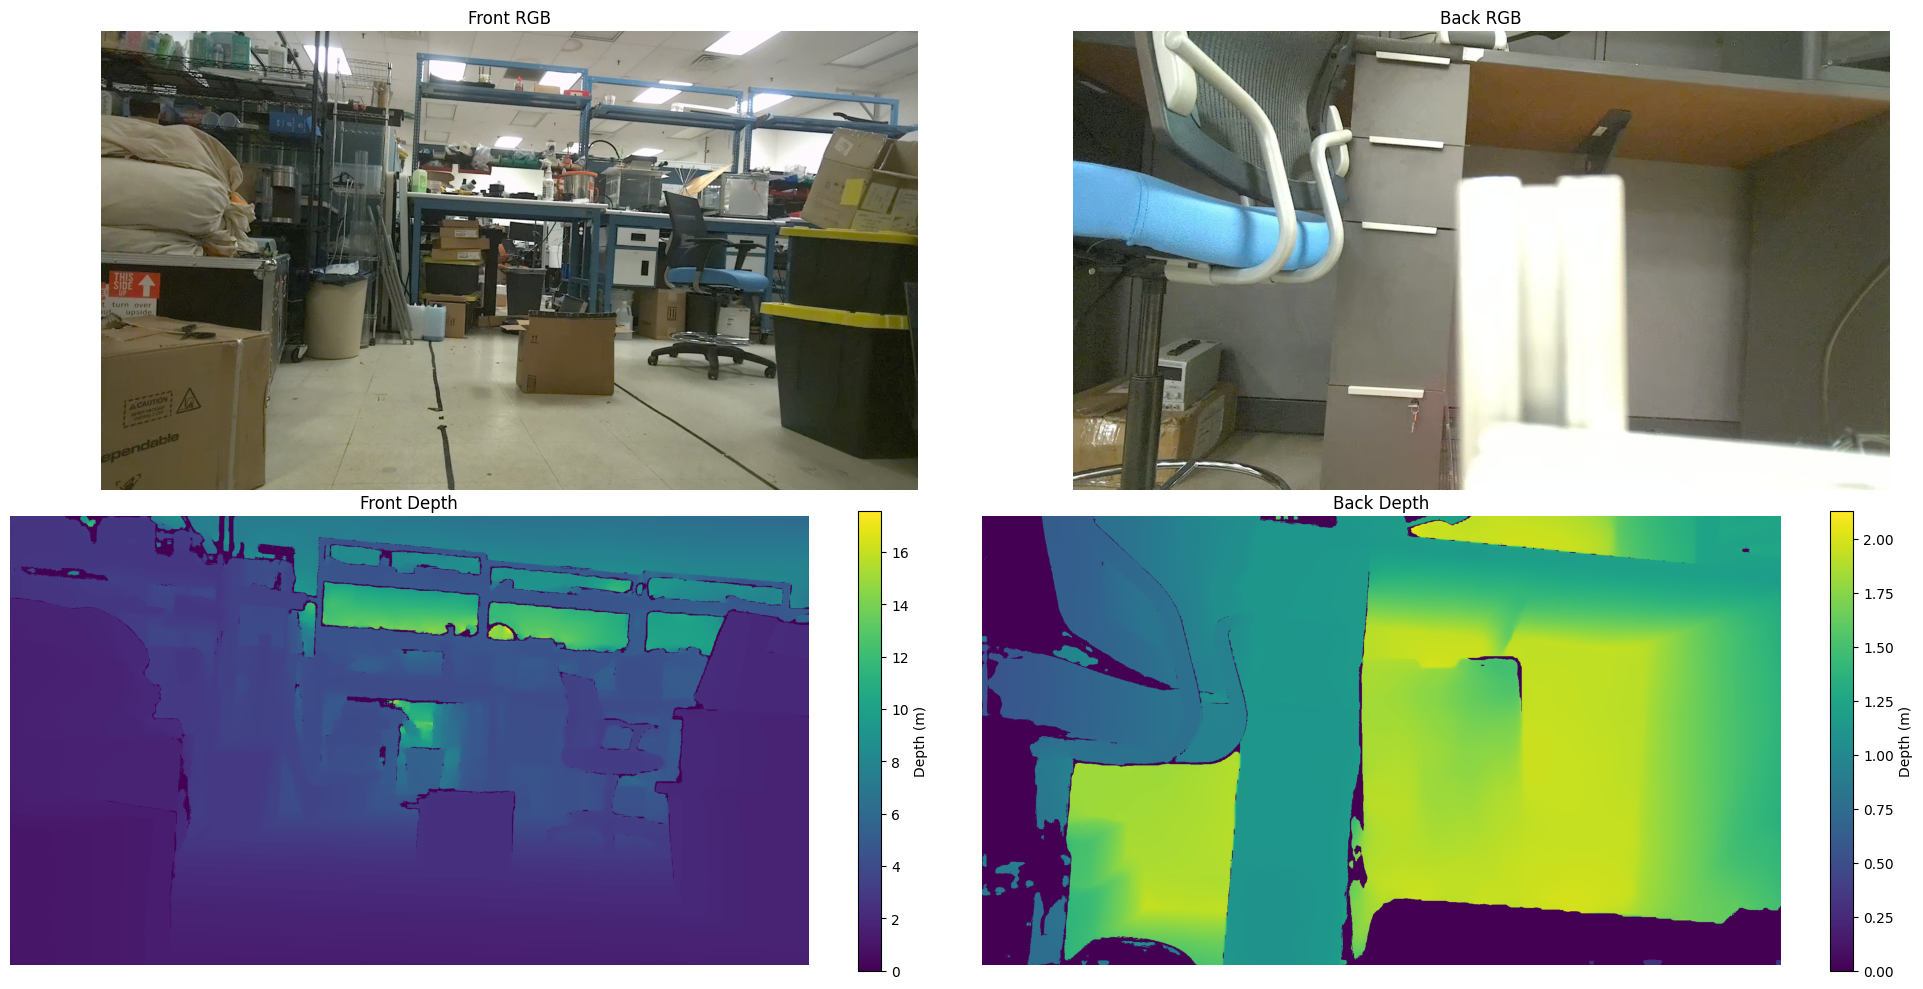

LiDAR visualization saved to: ./frame_lidar.png


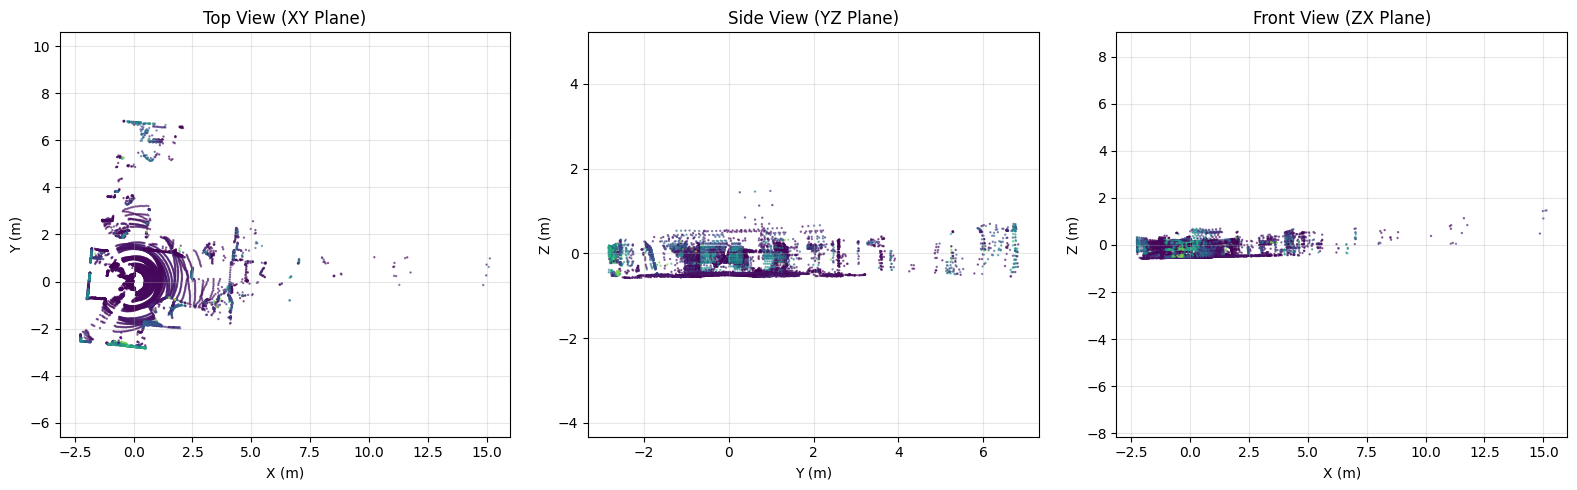

In [98]:

loader = DatasetLoader(dataset_dir)


frame_0 = loader.get_frame(1)
for key, value in frame_0.items():
    if value is not None:
        if isinstance(value, np.ndarray):
            print(f"  {key}: shape={value.shape}, dtype={value.dtype}")
        else:
            print(f"  {key}: {value}")
    else:
        print(f"  {key}: None")

visualize_frame(frame_0)